# Risk of losing privacy with rare categories

When dealing with data with rare categories, there is a risk of disclosing more information than intended about small groups.
The following example demonstrates how rare or unique categorical values can lead to overfitting and potentially increase disclosure risk.

The example uses a decision-tree-based synthesis method with a categorical predictor containing a unique value for every observation. Because the predictor uniquely identifies each observation, the decision tree can create homogeneous leaf nodes in which the target variable has only one possible value. Sampling from these leaf nodes therefore introduces little or no randomness, causing the synthetic target values to reproduce the original target values.

This example is intentionally constructed to demonstrate a potential failure mode. It does not imply that decision-tree-based synthesis methods will generally reproduce target variables exactly. Rather, it illustrates why the structure and cardinality of the input data should be considered when evaluating privacy.

While this example is constructed, it can happen when floating point data is unintentionally converted to strings.

## Demonstration of the problem

Suppose the following happens:

In [26]:
from sklearn.datasets import make_classification
from synthpop.utils import str_dtype
import pandas as pd
X, y = make_classification(
        random_state=42,
        n_samples=100,
        n_classes=10,
        n_informative=11,
    )
# By "accident", the floatingpoint numbers are cast to strings
X = X[:,0:1].astype(str_dtype)
X[0:3]

array([['1.3705361439967134'],
       ['-0.1115088271429437'],
       ['1.0587285298838789']], dtype=StringDType(na_object=nan))

The predictor column is now categorical, and every value is unique. 
We can use a decision-tree-based synthesis method to synthesise the target:

In [2]:
from synthpop.methods.cart_synth import TreeClassifierMethod
method = TreeClassifierMethod()

X = {i: X[:, i] for i in range(X.shape[1])}
y = y.astype(str_dtype)
synth_data = method.fit_transform(X,y)
y

array(['4', '0', '5', '1', '0', '1', '7', '6', '4', '4', '8', '0', '3',
       '0', '0', '6', '3', '7', '3', '0', '8', '6', '5', '9', '2', '0',
       '5', '6', '3', '3', '7', '7', '6', '6', '9', '2', '6', '8', '9',
       '7', '3', '9', '8', '1', '2', '5', '3', '9', '4', '2', '3', '5',
       '4', '9', '0', '7', '3', '0', '1', '4', '5', '2', '8', '6', '1',
       '3', '7', '8', '8', '7', '8', '9', '4', '9', '9', '4', '1', '7',
       '2', '4', '7', '0', '1', '1', '9', '6', '5', '5', '2', '2', '6',
       '8', '5', '1', '5', '2', '0', '8', '2', '4'],
      dtype=StringDType(na_object=nan))

In this example, the synthesised target is identical to the original target:

In [3]:
(synth_data == y).all()

np.True_

## Why does this happen?

This occurs because the decision tree is able to partition the observations into homogeneous leaf nodes. Each leaf contains observations with the same target value, so sampling a target value from a leaf does not introduce meaningful randomness.

The resulting tree illustrates this behaviour:

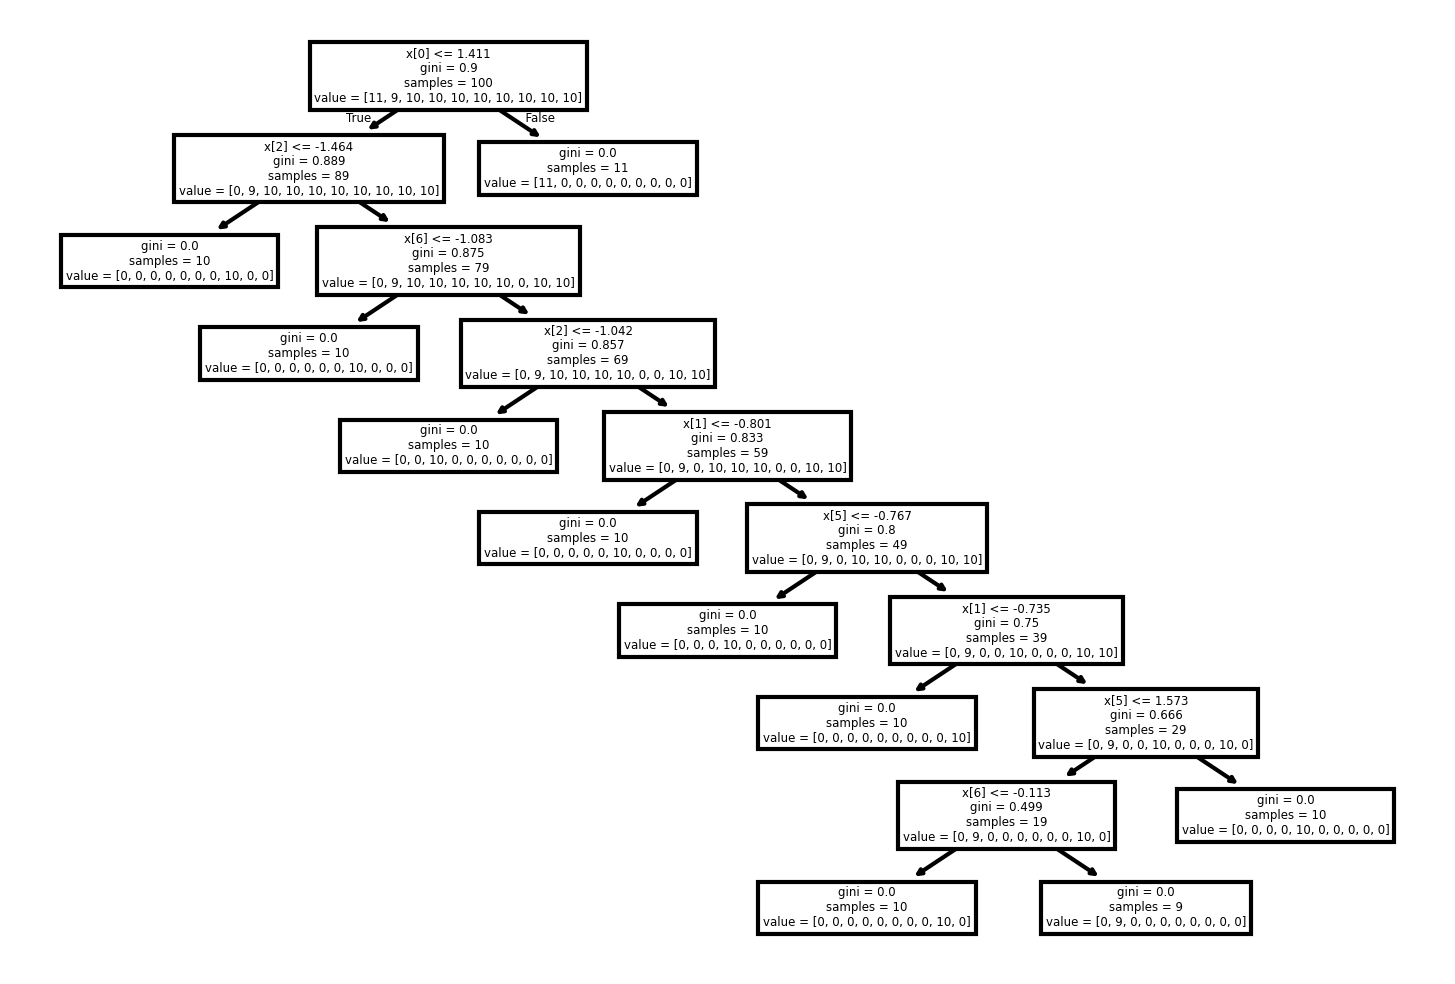

In [4]:
from sklearn import tree
from matplotlib import pyplot as plt
plt.figure(figsize=(6, 4), dpi=300)
tree.plot_tree(method.tree_)
plt.show()

Because the predictor contains 100 different values and the target contains only 10 possible values, the tree can separate observations into groups that are homogeneous with respect to the target. The synthesis model has therefore learned the relationship between the predictor and target too precisely for this dataset.

This is an example of [overfitting](https://en.wikipedia.org/wiki/Overfitting). In this case, the consequence of overfitting is a potential privacy risk: the synthesis process reproduces a relationship in the original data without introducing sufficient uncertainty.

A similar issue can occur in realistic datasets when a variable contains rare categories that are strongly associated with a sensitive variable. For example, suppose a dataset contains a rare category that identifies a small group of individuals and that group has a particular sensitive characteristic. If the synthesis model reproduces this relationship exactly, a third party with knowledge of the rare category may be able to infer the sensitive characteristic from the synthetic data.


## The impact of this problem

The example above is not realistic because the data used for fitting is the same as the data used to synthesise the target.
That is highly unlikely in realistic usecases. However, as the following example demonstrates, attribute disclosure would still happen.


In [5]:
import pandas as pd

df = pd.DataFrame({'X':X[0], 'y':y})
df['y'] = y
df

,X,y
0,1.3705361439967134,4
1,-0.1115088271429437,0
2,1.0587285298838789,5
3,1.0706105599791862,1
4,-1.1617838439123638,0
...,...,...
95,-0.5336003064391669,2
96,-1.2926253471522626,0
97,-0.16563141031763223,8
98,0.04522270899998256,2


In [24]:
from synthpop.synthesiser import Synthesiser
from synthpop.methods.copy_synth import CopyMethod
synth = Synthesiser()

synth.fit(df)
syn_df = synth.generate()
syn_df.merge(df,on="X",suffixes=("_syn","_observed"))

C:\Users\koome001\AppData\Local\pypoetry\Cache\virtualenvs\synthpop-py-O9_SKGOk-py3.13\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,X,y_syn,y_observed
0,1.0294574815983573,7,7
1,0.6654168236917787,5,5
2,-1.7938924978678903,8,8
3,-0.1131280525157404,4,4
4,0.42544486418417227,3,3
...,...,...,...
95,-0.695694877197064,4,4
96,0.9003985883950636,4,4
97,-0.16563141031763223,8,8
98,-0.9245641143780999,2,2


This example shows how attribute disclosure would happen in a realistic scenario. While fully reproducing the observed target is unlikely, The biggest privacy issue of rare categories is that the relation between variables is reproduced perfectly for those samples. This can lead to undesirable attribute disclosure. Changing the method for the first column to `CopyMethod` combined with a highly overfitted CART method for the second column does cause the complete observed dataset to be reproduced:

In [25]:
synth = Synthesiser(
    special_syn_method={"X": CopyMethod()}
)

synth.fit(df)
syn_df = synth.generate()

syn_df.equals(df)

True